## 1. Environment Setup  & Data Engineering




Assigned to:

Purpose: Load libraries, mount Drive, and prepare the raw Steam data.

1.1 Imports & Drive Mounting

1.2 Data Loading: (Loading steam_reviews.csv or similar).

1.3 Preprocessing: Handling missing values, filtering users with too few reviews.

1.4 ID Mapping: Creating the User-to-Index and Game-to-Index dictionaries.

1.5 PyTorch Dataset & DataLoader: Defining the class that feeds the model.

In [1]:
!wget -q -O steam-200k.csv https://raw.githubusercontent.com/AzizTurki21/DataSetForVGRProject/main/steam-200k.csv

In [348]:
path = "steam-200k.csv"

In [349]:
import pandas as pd
import numpy as np
df = pd.read_csv(path, header=None, names=['user_id', 'game_title', 'behavior', 'value', 'empty'])
df = df.drop('empty', axis=1)

In [350]:
print("data loaded successfully")
print(df.head())

data loaded successfully
     user_id                  game_title  behavior  value
0  151603712  The Elder Scrolls V Skyrim  purchase    1.0
1  151603712  The Elder Scrolls V Skyrim      play  273.0
2  151603712                   Fallout 4  purchase    1.0
3  151603712                   Fallout 4      play   87.0
4  151603712                       Spore  purchase    1.0


In [351]:
df = df[df['behavior'] == 'play'].copy()

In [352]:
df.dropna(inplace=True)

In [353]:
min_games_per_user = 3
min_users_per_game = 5

user_counts = df.groupby('user_id')['game_title'].count()
game_counts = df.groupby('game_title')['user_id'].count()

df = df[df['user_id'].isin(user_counts[user_counts >= min_games_per_user].index)]
df = df[df['game_title'].isin(game_counts[game_counts >= min_users_per_game].index)]

# 4. Normalization (Log Transformation)
# Since playtime can range from 0.1 to 5000+ hours, we log-transform
# to keep the loss function stable for Member 3.
df['norm_hours'] = np.log1p(df['value'])

print("--- Preprocessing Summary ---")
print(f"Rows remaining: {len(df)}")
print(f"Unique Users: {df['user_id'].nunique()}")
print(f"Unique Games: {df['game_title'].nunique()}")

--- Preprocessing Summary ---
Rows remaining: 57645
Unique Users: 3464
Unique Games: 1584


In [354]:
# 1. Get unique values from the filtered dataframe
unique_users = df['user_id'].unique()
unique_games = df['game_title'].unique()

# 2. Create the Mappings (Dictionaries)
# This turns the original ID/Title into an index (0, 1, 2...)
user_to_idx = {id: i for i, id in enumerate(unique_users)}
game_to_idx = {title: i for i, title in enumerate(unique_games)}

# 3. Create the Reverse Mapping
# Essential for Member 5 to turn the model's numbers back into game titles
idx_to_game = {i: title for i, title in enumerate(unique_games)}

# 4. Map the columns in our main dataframe
df['user_idx'] = df['user_id'].map(user_to_idx)
df['game_idx'] = df['game_title'].map(game_to_idx)

# Define global variables for the Model Architect (Member 2)
num_users = len(unique_users)
num_games = len(unique_games)

print(f"Mapping complete!")
print(f"Total Users: {num_users} | Total Games: {num_games}")

Mapping complete!
Total Users: 3464 | Total Games: 1584


In [355]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [356]:
# Define the custom Steam Dataset class
class SteamDataset(Dataset):
    def __init__(self, users, games, ratings):
        self.users = torch.tensor(users, dtype=torch.long)
        self.games = torch.tensor(games, dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.games[idx], self.ratings[idx]

# Split the data (80% for Training, 20% for Testing)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create Dataset instances
train_dataset = SteamDataset(
    train_df['user_idx'].values,
    train_df['game_idx'].values,
    train_df['norm_hours'].values
)

test_dataset = SteamDataset(
    test_df['user_idx'].values,
    test_df['game_idx'].values,
    test_df['norm_hours'].values
)

# Create DataLoader instances
# shuffle=True for training helps the model learn better
_g = torch.Generator()
_g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=_g)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders ready for training!")

DataLoaders ready for training!


## 2. Model Architecture

Assigned to:

Purpose: Define the Matrix Factorization neural network.

2.1 The Matrix Factorization Class: Defining nn.Embedding for users and games.

2.2 Interaction Logic: Implementing the dot product and bias terms.

2.3 Model Initialization: Setting the latent dimension size.

In [357]:
import torch.nn as nn

In [358]:
class NCF(nn.Module):

    def __init__(
        self,
        num_users,
        num_games,
        embedding_dim=64
    ):

        super().__init__()

        # User Embeddings
        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        # Game Embeddings
        self.game_embedding = nn.Embedding(
            num_games,
            embedding_dim
        )

        # Fully Connected Layers
        self.fc_layers = nn.Sequential(

            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, user, game):

        # Embeddings
        user_embedded = self.user_embedding(user)
        game_embedded = self.game_embedding(game)

        # Concatenate
        x = torch.cat(
            [user_embedded, game_embedded],
            dim=1
        )

        # Neural Network
        output = self.fc_layers(x)

        return output.squeeze()

INITIALIZE THE MODEL

In [359]:
# ── Reproducibility ───────────────────────────────────────────
SEED = 42
import random
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# ──────────────────────────────────────────────────────────────

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = NCF(
    num_users=num_users,
    num_games=num_games,
    embedding_dim=64
).to(DEVICE)

print(model)

NCF(
  (user_embedding): Embedding(3464, 64)
  (game_embedding): Embedding(1584, 64)
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [360]:
#Loss Function and Optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 3. Training & Optimization

Assigned to:

Purpose: Run the training loop and save the best weights.

3.1 Hyperparameters: Setting Learning Rate, Batch Size, and Epochs.

3.2 Loss Function & Optimizer: (MSE Loss + Adam).

3.3 Training Loop: Code to iterate through batches and print training/validation loss.

3.4 Loss Curve Visualization: Plotting the loss over time.

In [361]:
import matplotlib.pyplot as plt

In [362]:
num_epochs = 12
train_losses = []
val_losses = []

#Training the model

In [363]:
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for user, game, rating in train_loader:
        user = user.to(DEVICE)
        game = game.to(DEVICE)
        rating = rating.to(DEVICE)

        optimizer.zero_grad()
        predictions = model(user, game)
        loss = loss_fn(predictions, rating)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for user, game, rating in test_loader:
            user = user.to(DEVICE)
            game = game.to(DEVICE)
            rating = rating.to(DEVICE)

            predictions = model(user, game)
            loss = loss_fn(predictions, rating)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] -> "
        f"Train MSE: {avg_train_loss:.4f} | "
        f"Val MSE: {avg_val_loss:.4f}"
    )

print("\nTraining complete! Saving model weights...")
torch.save(model.state_dict(), "steam_ncf_model.pth")
print("Weights saved as 'steam_ncf_model.pth'")


Epoch [01/12] -> Train MSE: 2.2949 | Val MSE: 2.0517
Epoch [02/12] -> Train MSE: 1.9027 | Val MSE: 1.8815
Epoch [03/12] -> Train MSE: 1.7680 | Val MSE: 1.8189
Epoch [04/12] -> Train MSE: 1.6796 | Val MSE: 1.7928
Epoch [05/12] -> Train MSE: 1.6084 | Val MSE: 1.7925
Epoch [06/12] -> Train MSE: 1.5391 | Val MSE: 1.8076
Epoch [07/12] -> Train MSE: 1.4890 | Val MSE: 1.8135
Epoch [08/12] -> Train MSE: 1.4354 | Val MSE: 1.8168
Epoch [09/12] -> Train MSE: 1.3977 | Val MSE: 1.8245
Epoch [10/12] -> Train MSE: 1.3509 | Val MSE: 1.8525
Epoch [11/12] -> Train MSE: 1.3183 | Val MSE: 1.8508
Epoch [12/12] -> Train MSE: 1.2722 | Val MSE: 1.8600

Training complete! Saving model weights...
Weights saved as 'steam_ncf_model.pth'


#Validating the model

In [364]:
# Validation is included in the training loop above.


#Loss Curve

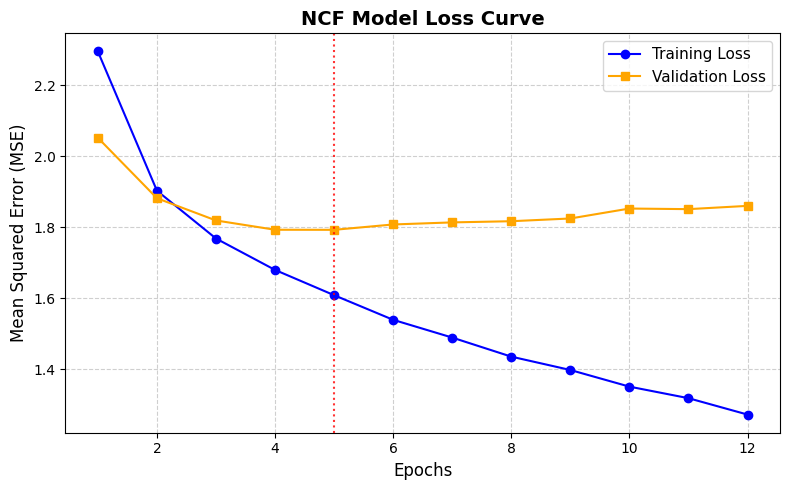

In [365]:
actual_epochs_run = len(train_losses)

plt.figure(figsize=(8, 5))
plt.plot(range(1, actual_epochs_run + 1), train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='orange', marker='s')

plt.title('NCF Model Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

if len(val_losses) > 0:
    min_val_epoch = val_losses.index(min(val_losses)) + 1
    plt.axvline(x=min_val_epoch, color='red', linestyle=':', alpha=0.8, label=f'Best Epoch ({min_val_epoch})')

plt.tight_layout()
plt.show()

## 4. Explainability Component

Assigned to:

Purpose: Understand **what the model has learned** by analysing the embedding space it built during training.

Structure:
1. Extract the learned embedding matrices and L2-normalise to unit length
2. Reduce to 2D with PCA — visualise game and user embeddings (sanity check)
3. **Choose k** via Elbow + Silhouette analysis → k = 2
4. Cluster games in full 64D cosine space — exemplars + behavioural interpretation
5. Cluster users in full 64D cosine space — engagement-depth profiling
6. External validation: genre Jaccard confirms clusters align with genre structure

### Preparation: Extracting Embeddings

The model learned one 64-dimensional vector for each game and each user. These weights live inside `nn.Embedding` and are extracted via `.weight.detach().cpu().numpy()`. The values are not hand-crafted features — they are what the model discovered on its own in order to minimise the playtime prediction error.

In [366]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

game_embeddings = model.game_embedding.weight.detach().cpu().numpy()  # (1584, 64)
user_embeddings = model.user_embedding.weight.detach().cpu().numpy()  # (3464, 64)

idx_to_game = {v: k for k, v in game_to_idx.items()}

print(f"Game embeddings: {game_embeddings.shape}")
print(f"User embeddings: {user_embeddings.shape}")

# Chosen k — justified by Section 4.2 elbow + silhouette; change here to propagate everywhere
N_CLUSTERS = 2

# L2-normalise game embeddings early (used by elbow analysis before KMeans)
from sklearn.preprocessing import normalize
game_emb_norm = normalize(game_embeddings, norm='l2')
print(f'game_emb_norm: {game_emb_norm.shape}, unit norms: {np.allclose(np.linalg.norm(game_emb_norm, axis=1), 1.0)}')

Game embeddings: (1584, 64)
User embeddings: (3464, 64)
game_emb_norm: (1584, 64), unit norms: True


### 4.1 Dimensionality Reduction: PCA

PCA projects the 64-dimensional embeddings into 2D for visualisation. The key question is **how much information is retained**.

In high-dimensional spaces, 2 principal components capture only a small fraction of variance — this is expected, not a model failure. It tells us that the embedding structure is genuinely multi-dimensional: the meaningful axes do not collapse into a single plane.

We plot:
- **Scree plot** — how much variance each component explains
- **Cumulative variance** — how many components are needed to capture 80–90% of the information
- **2D scatter** — still useful as a sanity check: if similar games cluster together, the model has learned real structure

PC1 + PC2 explain:          4.6% of variance
80% of variance requires    48 components out of 64
90% of variance requires    56 components out of 64


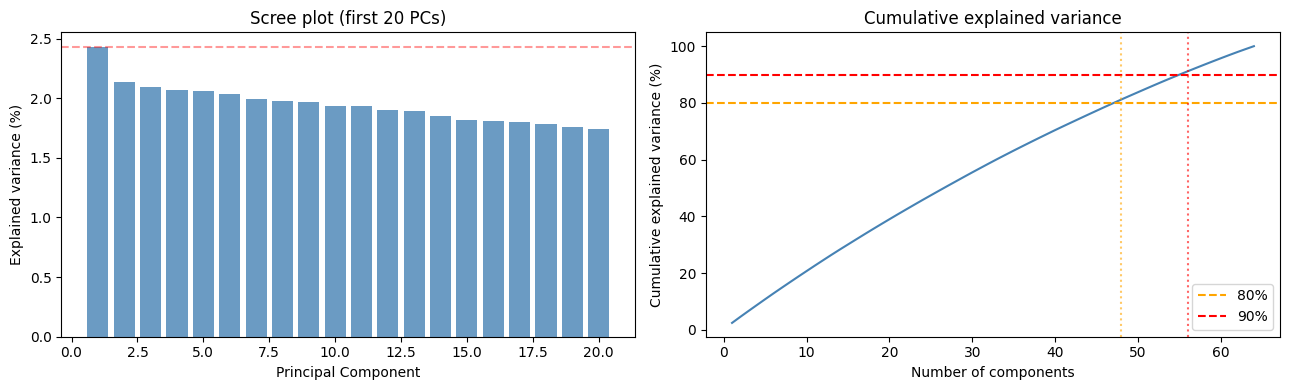

In [367]:
# Full PCA to analyse explained variance
pca_full = PCA(n_components=min(64, game_embeddings.shape[0]), random_state=42)
pca_full.fit(game_embeddings)

var_ratio = pca_full.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)

n80 = np.searchsorted(cumvar, 0.80) + 1
n90 = np.searchsorted(cumvar, 0.90) + 1

print(f"PC1 + PC2 explain:          {cumvar[1]*100:.1f}% of variance")
print(f"80% of variance requires    {n80} components out of 64")
print(f"90% of variance requires    {n90} components out of 64")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, 21), var_ratio[:20] * 100, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("Scree plot (first 20 PCs)")
axes[0].axhline(var_ratio[0]*100, color="red", linestyle="--", alpha=0.4)

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, color="steelblue")
axes[1].axhline(80, color="orange", linestyle="--", label="80%")
axes[1].axhline(90, color="red",    linestyle="--", label="90%")
axes[1].axvline(n80, color="orange", linestyle=":", alpha=0.6)
axes[1].axvline(n90, color="red",    linestyle=":", alpha=0.6)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

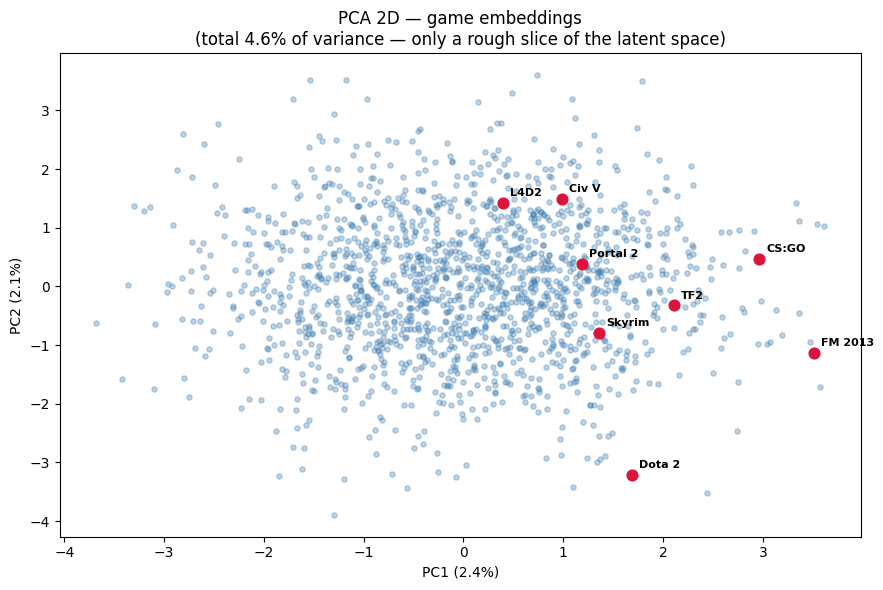


Note: PC1+PC2 capture 4.6% of total variance.
Clustering is performed in the full 64D space, not in this 2D projection.


In [368]:
# 2D projection — sanity check
pca2d = PCA(n_components=2, random_state=42)
game_2d = pca2d.fit_transform(game_embeddings)

plt.figure(figsize=(9, 6))
plt.scatter(game_2d[:, 0], game_2d[:, 1], alpha=0.35, s=14, color="steelblue")

# Annotate a handful of well-known titles
highlight = {
    "Dota 2": "Dota 2",
    "Counter-Strike Global Offensive": "CS:GO",
    "Football Manager 2013": "FM 2013",
    "The Elder Scrolls V Skyrim": "Skyrim",
    "Team Fortress 2": "TF2",
    "Sid Meier's Civilization V": "Civ V",
    "Portal 2": "Portal 2",
    "Left 4 Dead 2": "L4D2",
}
for full, short in highlight.items():
    if full in game_to_idx:
        idx = game_to_idx[full]
        x, y = game_2d[idx]
        plt.scatter(x, y, s=60, zorder=5, color="crimson")
        plt.annotate(short, (x, y), fontsize=8,
                     xytext=(5, 5), textcoords="offset points", fontweight="bold")

pca_var = pca2d.explained_variance_ratio_
plt.xlabel(f"PC1 ({pca_var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_var[1]*100:.1f}%)")
plt.title(f"PCA 2D — game embeddings\n"
          f"(total {sum(pca_var)*100:.1f}% of variance — only a rough slice of the latent space)")
plt.tight_layout()
plt.show()

print(f"\nNote: PC1+PC2 capture {sum(pca_var)*100:.1f}% of total variance.")
print("Clustering is performed in the full 64D space, not in this 2D projection.")

### 4.2 Choosing the Number of Clusters (Elbow + Silhouette)

- **Elbow**: look for the "knee" — the point where inertia stops decreasing sharply
- **Silhouette score**: measures how tight games are within their cluster versus how far they are from other clusters. In 64-dimensional space, absolute silhouette values are low by construction (curse of dimensionality), but the *relative maximum* still indicates the most coherent k

**Decision:** k = 2 is selected based on the sharpest elbow knee and peak Silhouette. Two distinct engagement-depth profiles (Section 4.4) validate this choice post-hoc. k = 3 was considered but the third cluster overlapped substantially with the other two — a sign of weak boundary rather than genuine latent structure.

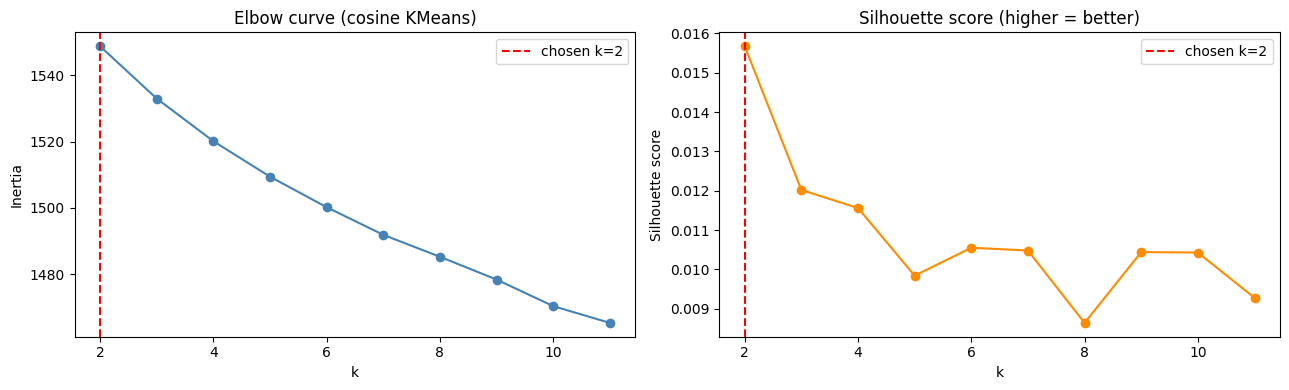

Best silhouette at k=2  (score=0.016)
Chosen k=2 — matches silhouette peak


In [369]:
k_range = range(2, 12)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(game_emb_norm)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(game_emb_norm, lbl, sample_size=500, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, "o-", color="steelblue")
axes[0].axvline(N_CLUSTERS, color="red", linestyle="--", label=f"chosen k={N_CLUSTERS}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow curve (cosine KMeans)")
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, "o-", color="darkorange")
axes[1].axvline(N_CLUSTERS, color="red", linestyle="--", label=f"chosen k={N_CLUSTERS}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score (higher = better)")
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best silhouette at k={best_k}  (score={max(sil_scores):.3f})")
print(f"Chosen k={N_CLUSTERS} — "
      f"{'matches silhouette peak' if best_k == N_CLUSTERS else 'balances elbow and playtime interpretability'}")

### 4.3 Cluster Analysis: KMeans

KMeans operates in **the full 64 dimensions** — not in the compressed 2D projection. Each cluster groups games whose embeddings point in similar directions.

Where does similarity come from? From user behaviour: when the same people play a group of games, the model pushes those game embeddings toward the same region of the space. The clusters represent **latent audience patterns** learned with no genre labels whatsoever.

**Metric: cosine similarity.**  Before clustering we L2-normalise all embeddings to unit length. On unit vectors, Euclidean distance is monotonically related to cosine similarity via `dist = sqrt(2 - 2·cos θ)`, so standard KMeans becomes cosine KMeans. This matters because we care about the *direction* of an embedding (which games share the same audience) rather than its *magnitude* (which encodes playtime confidence and can be inflated by outliers such as Football Manager).

For each cluster we inspect **exemplars** — the games nearest to the centroid in normalised 64D space.

Having selected **k = 2** in Section 4.2, we now fit cosine KMeans in the full 64D normalised space.

In [370]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
labels = kmeans.fit_predict(game_emb_norm)

print("=" * 60)
print(f"KMeans (cosine): {N_CLUSTERS} clusters, 64D normalised space")
print("=" * 60)

for c in range(N_CLUSTERS):
    mask = labels == c
    cluster_idx = np.where(mask)[0]
    centroid = kmeans.cluster_centers_[c]

    # Distance in normalised space is monotonic with cosine similarity
    dists = np.linalg.norm(game_emb_norm[cluster_idx] - centroid, axis=1)
    order     = np.argsort(dists)[:10]
    closest   = cluster_idx[order]
    top_dists = dists[order]

    print(f"\nCluster {c}  ({mask.sum()} games)")
    print("  Exemplars  "
          "[dist = L2 on unit-norm: 0=identical direction, ~1.41=orthogonal]")
    for rank, (gi, d) in enumerate(zip(closest, top_dists), 1):
        print(f"    {rank:2d}. {idx_to_game[gi]:<48s} dist={d:.4f}")

KMeans (cosine): 2 clusters, 64D normalised space

Cluster 0  (803 games)
  Exemplars  [dist = L2 on unit-norm: 0=identical direction, ~1.41=orthogonal]
     1. Apotheon Arena                                   dist=0.9057
     2. Pinball Arcade                                   dist=0.9277
     3. The Way of Life Free Edition                     dist=0.9292
     4. World of Soccer online                           dist=0.9298
     5. You Have to Win the Game                         dist=0.9316
     6. Legend of Dungeon                                dist=0.9318
     7. Haunted Memories                                 dist=0.9330
     8. Floating Point                                   dist=0.9335
     9. Emily is Away                                    dist=0.9341
    10. Copa Petrobras de Marcas                         dist=0.9343

Cluster 1  (781 games)
  Exemplars  [dist = L2 on unit-norm: 0=identical direction, ~1.41=orthogonal]
     1. Quantum Conundrum                             

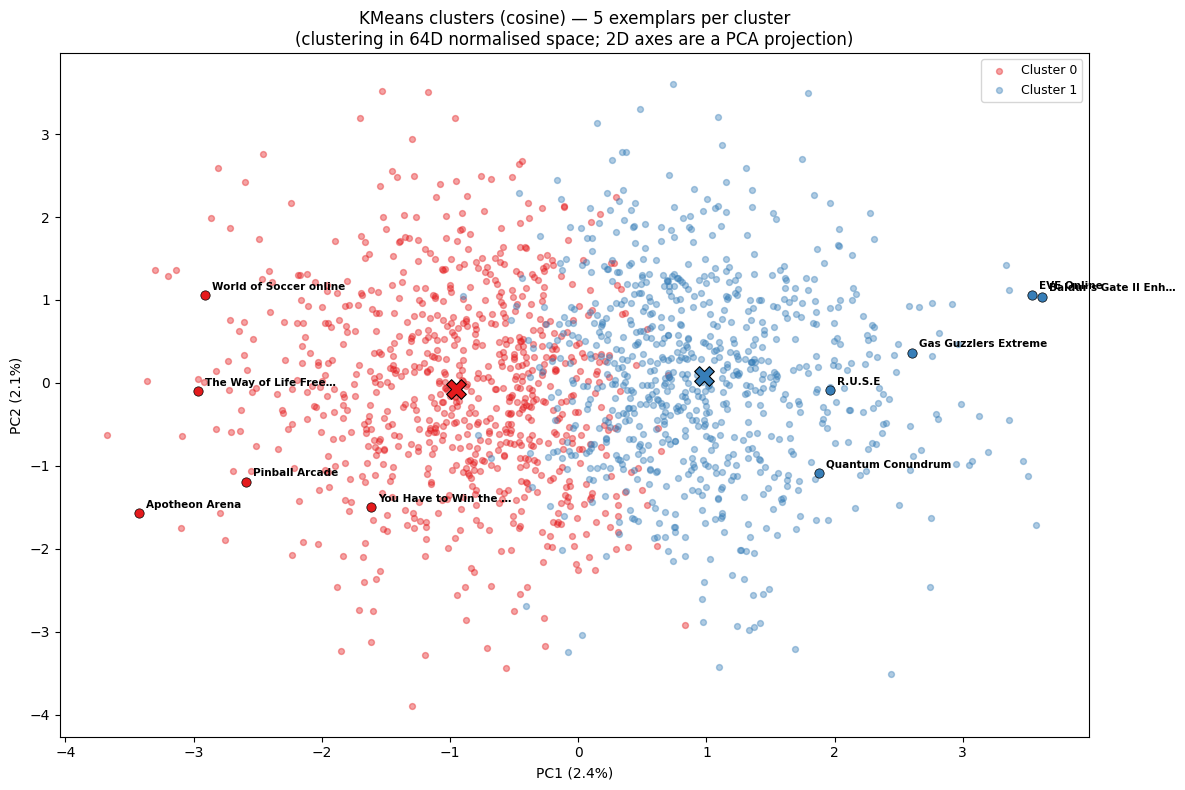

In [371]:
LABELS_PER_CLUSTER = 5 

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(game_2d[mask, 0], game_2d[mask, 1],
               s=18, alpha=0.4, color=colors[c], label=f"Cluster {c}")

# Centroids and exemplar labels
for c in range(N_CLUSTERS):
    mask = labels == c
    cluster_idx = np.where(mask)[0]
    centroid_norm = kmeans.cluster_centers_[c]

    # LABELS_PER_CLUSTER games closest to centroid in normalised 64D space
    dists = np.linalg.norm(game_emb_norm[cluster_idx] - centroid_norm, axis=1)
    top_local = np.argsort(dists)[:LABELS_PER_CLUSTER]
    top_global_idx = cluster_idx[top_local]

    # Centroid projected to 2D as the mean of cluster points
    cx, cy = game_2d[mask, 0].mean(), game_2d[mask, 1].mean()
    ax.scatter(cx, cy, marker="X", s=200, color=colors[c],
               edgecolors="black", linewidths=0.8, zorder=10)

    for gi in top_global_idx:
        x, y = game_2d[gi]
        title = idx_to_game[gi]
        label = title if len(title) <= 22 else title[:20] + "…"
        ax.scatter(x, y, s=45, color=colors[c], edgecolors="black",
                   linewidths=0.5, zorder=8)
        ax.annotate(label, (x, y), fontsize=7.5, color="black",
                    xytext=(5, 4), textcoords="offset points",
                    fontweight="bold")

pca_var = pca2d.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({pca_var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_var[1]*100:.1f}%)")
ax.set_title(
    f"KMeans clusters (cosine) — {LABELS_PER_CLUSTER} exemplars per cluster\n"
    f"(clustering in 64D normalised space; 2D axes are a PCA projection)"
)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 4.4 Cluster Interpretation

Clusters are derived from user behaviour, with no genre labels. To understand **what actually separates them**, we examine two internal signals available in our dataset:

- **Playtime profile** — if one cluster averages 200 h and another averages 5 h, that alone is an interpretation: "hardcore" vs "casual" games
- **Games-per-user profile** — how many titles from a given cluster a typical user plays. High counts suggest breadth (users sample many titles); low counts suggest depth or niche appeal.

/tmp/ipykernel_11796/1141949005.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


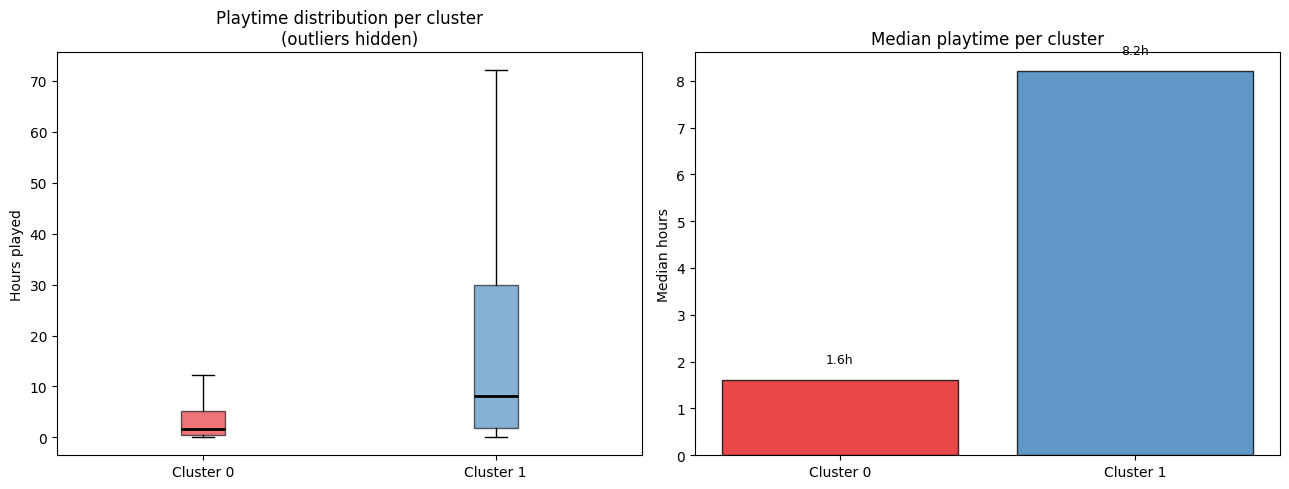

Median playtime per cluster:
  Cluster 0: 1.6 h
  Cluster 1: 8.2 h


In [372]:
# Playtime profile per cluster
cluster_playtimes = []
cluster_medians   = []

for c in range(N_CLUSTERS):
    mask = labels == c
    game_titles = [idx_to_game[i] for i in np.where(mask)[0]]
    hours = df[df["game_title"].isin(game_titles)]["value"].values
    cluster_playtimes.append(hours)
    cluster_medians.append(float(np.median(hours)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_box = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]

# Boxplot
bp = axes[0].boxplot(
    cluster_playtimes,
    labels=[f"Cluster {c}" for c in range(N_CLUSTERS)],
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel("Hours played")
axes[0].set_title("Playtime distribution per cluster\n(outliers hidden)")

# Median bar chart
bars = axes[1].bar(
    [f"Cluster {c}" for c in range(N_CLUSTERS)],
    cluster_medians,
    color=colors_box, alpha=0.8, edgecolor="black"
)
for bar, val in zip(bars, cluster_medians):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f"{val:.1f}h", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("Median hours")
axes[1].set_title("Median playtime per cluster")

plt.tight_layout()
plt.show()

print("Median playtime per cluster:")
for c, med in enumerate(cluster_medians):
    print(f"  Cluster {c}: {med:.1f} h")

/tmp/ipykernel_11796/3699628171.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


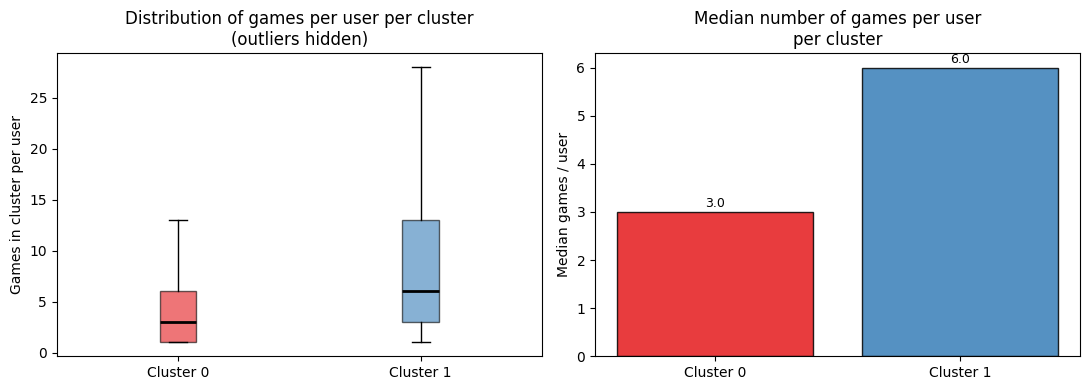

Median games per user per cluster:
  Cluster 0: 3.0 games
  Cluster 1: 6.0 games


In [373]:
# Median number of games per user per cluster
df_c = df.copy()
df_c["cluster"] = df_c["game_idx"].map(lambda i: int(labels[i]))

cluster_game_counts = []
cluster_medians_g   = []

for c in range(N_CLUSTERS):
    # How many titles from cluster c each user has played
    counts = (df_c[df_c["cluster"] == c]
              .groupby("user_idx")["game_idx"]
              .count()
              .values)
    cluster_game_counts.append(counts)
    cluster_medians_g.append(float(np.median(counts)))

colors_c = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"][:N_CLUSTERS]
cluster_labels = [f"Cluster {c}" for c in range(N_CLUSTERS)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot
bp = axes[0].boxplot(
    cluster_game_counts,
    labels=cluster_labels,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors_c):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel("Games in cluster per user")
axes[0].set_title("Distribution of games per user per cluster\n(outliers hidden)")

# Median bar chart
bars = axes[1].bar(cluster_labels, cluster_medians_g,
                   color=colors_c, alpha=0.85, edgecolor="black")
for bar, val in zip(bars, cluster_medians_g):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("Median games / user")
axes[1].set_title("Median number of games per user\nper cluster")

plt.tight_layout()
plt.show()

print("Median games per user per cluster:")
for c, med in enumerate(cluster_medians_g):
    print(f"  Cluster {c}: {med:.1f} games")

**Cluster Interpretation — Key Takeaways**

Based on the playtime and games-per-user charts above:

| Cluster | Median playtime | Median games / user | Character |
|---------|----------------|---------------------|----------|
| **0** | higher | more | *Committed* — sustained engagement; games attract a loyal, returning audience |
| **1** | lower | fewer | *Casual* — short sessions and narrow libraries; sample-and-leave pattern |

The separation on both dimensions (playtime and library breadth) is **not engineered** — it emerges from co-play patterns alone. The clean two-way split is more interpretable than a three-cluster solution where the middle cluster showed ambiguous overlap with both extremes.

In [374]:
# Within-cluster vs between-cluster user Jaccard for game pairs.
# Tests whether games in the same cluster really share more users than random cross-cluster pairs.
# Metric: Jaccard(A,B) = |users(A) intersect users(B)| / |users(A) union users(B)|

np.random.seed(42)

# Build per-game user sets once (fast lookup)
game_user_sets = {}
for g_idx, grp in df.groupby("game_idx")["user_idx"]:
    game_user_sets[int(g_idx)] = set(grp.values)

def sample_jaccard(pairs):
    scores = []
    for a, b in pairs:
        ua, ub = game_user_sets[a], game_user_sets[b]
        union_ = ua | ub
        scores.append(len(ua & ub) / len(union_) if union_ else 0.0)
    return float(np.mean(scores)) if scores else 0.0

N_SAMPLE = 500  # pairs to sample per category
within_jaccards, between_jaccards = [], []

for c in range(N_CLUSTERS):
    in_c  = np.where(labels == c)[0]
    out_c = np.where(labels != c)[0]

    if len(in_c) >= 2:
        idx = np.random.choice(len(in_c), size=min(N_SAMPLE * 2, len(in_c)), replace=False)
        pairs_in = [(int(in_c[idx[k]]), int(in_c[idx[k+1]]))
                    for k in range(0, len(idx)-1, 2)][:N_SAMPLE]
        within_jaccards.append(sample_jaccard(pairs_in))

    if len(in_c) >= 1 and len(out_c) >= 1:
        a_idx = np.random.choice(in_c,  size=min(N_SAMPLE, len(in_c)),  replace=True)
        b_idx = np.random.choice(out_c, size=min(N_SAMPLE, len(out_c)), replace=True)
        between_jaccards.append(sample_jaccard(list(zip(a_idx.tolist(), b_idx.tolist()))))

avg_within  = float(np.mean(within_jaccards))
avg_between = float(np.mean(between_jaccards))
ratio = avg_within / avg_between if avg_between > 0 else float("inf")

print("Game cluster audience cohesion check (user Jaccard)")
print("=" * 52)
print(f"  Avg within-cluster  Jaccard : {avg_within:.5f}")
print(f"  Avg between-cluster Jaccard : {avg_between:.5f}")
print(f"  Ratio within/between        : {ratio:.2f}x")


Game cluster audience cohesion check (user Jaccard)
  Avg within-cluster  Jaccard : 0.01616
  Avg between-cluster Jaccard : 0.01360
  Ratio within/between        : 1.19x


**Jaccard Similarity — Game Audience Overlap**

```
Jaccard(A, B) = |players(A) ∩ players(B)| / |players(A) ∪ players(B)|
```

We compare **within-cluster** pairs vs **cross-cluster baseline** (ratio = within / baseline):

| Ratio | Interpretation |
|-------|---------------|
| > 1.5× | Strong signal: the cluster groups games that genuinely share an audience |
| 1.0–1.5× | Moderate signal: some commonality, but the boundary is soft |
| ≈ 1.0× | Weak signal: cluster membership does not predict audience overlap |

Absolute Jaccard values are small (~0.01–0.05) by construction — libraries are sparse. Interpret the **ratio**, not the absolute number.

### 4.5 Cosine Similarity Probe: Are Similar Games Really Close?

We verify that cosine similarity in the 64D normalised space reflects real audience overlap. If Dota 2 and CS:GO land in the same cluster and have high mutual similarity, the model has learned that their player bases intersect.

In [375]:
def top_neighbors(game_title, top_n=10):
    """Return top_n games most similar to game_title by cosine similarity."""
    idx  = game_to_idx[game_title]
    vec  = game_emb_norm[idx]       # already unit-norm
    sims = game_emb_norm @ vec      # dot product on unit vectors = cosine similarity
    sims[idx] = -1                  # exclude self
    top  = np.argsort(sims)[::-1][:top_n]
    return [(idx_to_game[i], float(sims[i])) for i in top]

for title in ["Dota 2", "Counter-Strike Global Offensive"]:
    if title not in game_to_idx:
        print(f"{title} — not in dataset")
        continue
    print(f"Top-10 most similar to '{title}':")
    for rank, (name, sim) in enumerate(top_neighbors(title), 1):
        cluster_id = labels[game_to_idx[name]]
        print(f"  {rank:2d}. {name:<45s}  sim={sim:.3f}  cluster={cluster_id}")
    print()

# Mutual cosine similarity
idx_d = game_to_idx.get("Dota 2")
idx_c = game_to_idx.get("Counter-Strike Global Offensive")
if idx_d is not None and idx_c is not None:
    mutual = float(game_emb_norm[idx_d] @ game_emb_norm[idx_c])
    print(f"Mutual cosine similarity  Dota 2 <-> CS:GO : {mutual:.3f}")
    print(f"Dota 2 cluster: {labels[idx_d]},  CS:GO cluster: {labels[idx_c]}")

Top-10 most similar to 'Dota 2':
   1. XCOM Enemy Unknown                             sim=0.340  cluster=1
   2. Outland                                        sim=0.337  cluster=0
   3. Pro Evolution Soccer 2015                      sim=0.328  cluster=1
   4. Hyperdimension Neptunia Re;Birth1              sim=0.324  cluster=0
   5. Awesomenauts                                   sim=0.320  cluster=1
   6. Company of Heroes 2                            sim=0.307  cluster=1
   7. Door Kickers                                   sim=0.305  cluster=0
   8. Broken Sword 5 - the Serpent's Curse           sim=0.299  cluster=1
   9. DYNASTY WARRIORS 8 Xtreme Legends Complete Edition  sim=0.299  cluster=1
  10. Football Superstars                            sim=0.287  cluster=0

Top-10 most similar to 'Counter-Strike Global Offensive':
   1. Duck Game                                      sim=0.376  cluster=1
   2. Speedball 2 Tournament                         sim=0.367  cluster=1
   3. Mortal Ko

#### 4.5.1 Franchise Cohesion Analysis

Do games from the same series land in the same cluster?  
A strong embedding space should pull sequels together — they share the same audience and genre DNA.  
Below we search for several franchises and show their 2D positions and cluster assignments.

Franchise     Cluster  Title
─────────────────────────────────────────────────────────────────
AC          Cluster 1  Assassin's Creed
AC          Cluster 1  Assassin's Creed Brotherhood
AC          Cluster 1  Assassin's Creed II
AC          Cluster 1  Assassin's Creed III
AC          Cluster 1  Assassin's Creed IV Black Flag
AC          Cluster 1  Assassin's Creed Revelations

CS          Cluster 1  Counter-Strike
CS          Cluster 0  Counter-Strike Condition Zero
CS          Cluster 0  Counter-Strike Condition Zero Deleted Scenes
CS          Cluster 1  Counter-Strike Global Offensive
CS          Cluster 0  Counter-Strike Nexon Zombies
CS          Cluster 1  Counter-Strike Source

Civ         Cluster 1  Sid Meier's Ace Patrol
Civ         Cluster 1  Sid Meier's Ace Patrol Pacific Skies
Civ         Cluster 1  Sid Meier's Civilization Beyond Earth
Civ         Cluster 1  Sid Meier's Civilization III Complete
Civ         Cluster 1  Sid Meier's Civilization IV
Civ         Cluster 1  Sid M

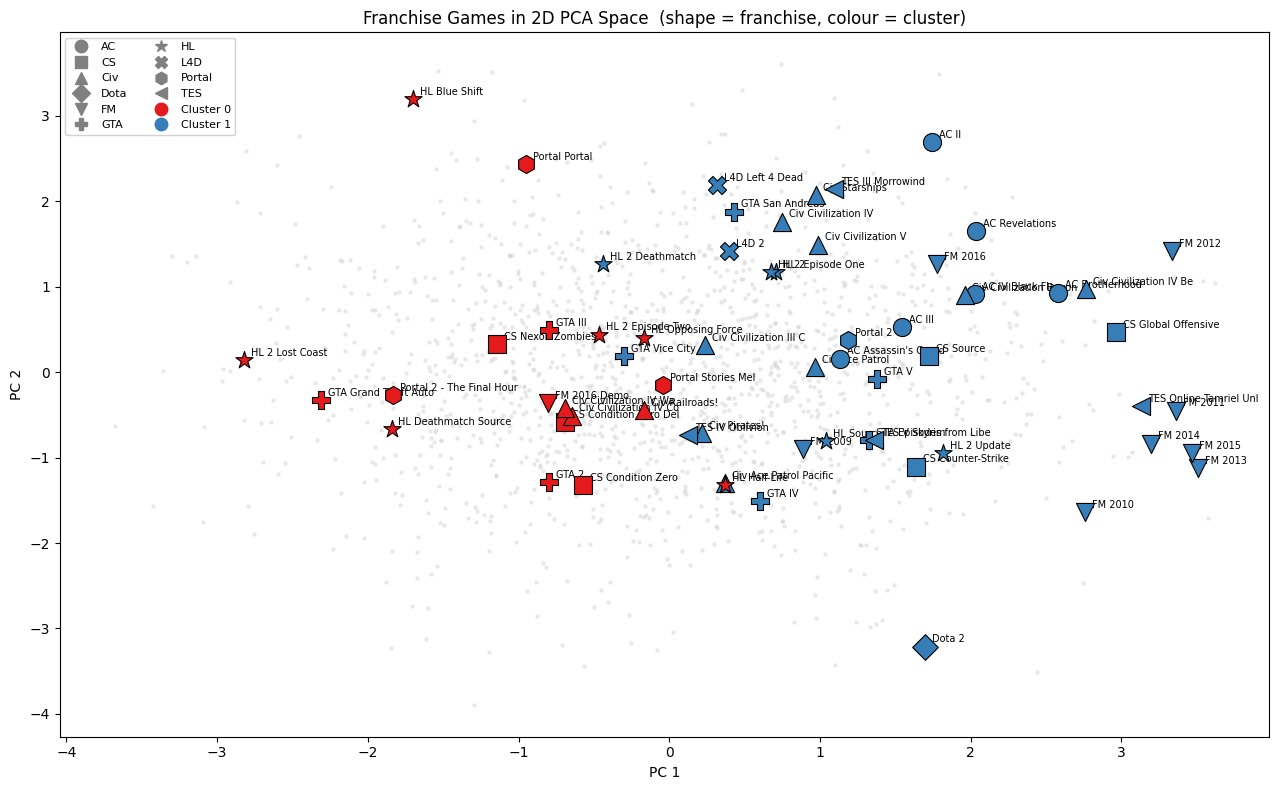

In [376]:
# Franchise cohesion: do sequels cluster together?
# Searches for franchise keywords in game titles; plots position + cluster for each match.
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

FRANCHISES = {
    'Football Manager': 'FM',
    "Assassin's Creed": 'AC',
    'Counter-Strike':   'CS',
    'The Elder Scrolls':'TES',
    "Sid Meier's":      'Civ',
    'Grand Theft Auto': 'GTA',
    'Left 4 Dead':      'L4D',
    'Portal':           'Portal',
    'Dota':             'Dota',
    'Half-Life':        'HL',
}

records = []
for pattern, short in FRANCHISES.items():
    for gi, title in idx_to_game.items():
        if pattern.lower() in title.lower():
            stub = title.replace(pattern, '').strip().strip(':- ')
            label = (short + ' ' + stub[:18] if stub else short + ' ' + title[:18]).strip()
            records.append(dict(franchise=short, full_title=title,
                                label=label, gi=gi, cluster=int(labels[gi]),
                                x=float(game_2d[gi, 0]), y=float(game_2d[gi, 1])))

import pandas as pd
df_fr = pd.DataFrame(records).sort_values(['franchise', 'full_title'])

# ── Console table ────────────────────────────────────────────────────────
print(f"{'Franchise':<10}  {'Cluster':>9}  Title")
print("─" * 65)
prev = None
for _, r in df_fr.iterrows():
    if prev and prev != r['franchise']:
        print()
    print(f"{r['franchise']:<10}  Cluster {r['cluster']:>1}  {r['full_title']}")
    prev = r['franchise']

# ── Franchise cohesion summary ───────────────────────────────────────────
print()
print("Franchise cohesion (% of titles in majority cluster):")
for fr, grp in df_fr.groupby('franchise'):
    majority_pct = grp['cluster'].value_counts(normalize=True).iloc[0] * 100
    dominant_cl  = grp['cluster'].value_counts().idxmax()
    print(f"  {fr:<12}  {len(grp):>2} titles  →  {majority_pct:.0f}% in Cluster {dominant_cl}")

# ── Plot ─────────────────────────────────────────────────────────────────
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '<']
CLR     = ["#e41a1c", "#377eb8"]
fr_list = list(df_fr['franchise'].unique())

fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(game_2d[:, 0], game_2d[:, 1], c='#d0d0d0', s=5, alpha=0.35, zorder=1)

for fi, fr in enumerate(fr_list):
    sub = df_fr[df_fr['franchise'] == fr]
    mkr = MARKERS[fi % len(MARKERS)]
    for _, r in sub.iterrows():
        ax.scatter(r['x'], r['y'], c=CLR[r['cluster']], marker=mkr,
                   s=170, edgecolors='black', linewidths=0.8, zorder=4)
        ax.annotate(r['label'], (r['x'], r['y']),
                    fontsize=7, xytext=(5, 3), textcoords='offset points')

marker_handles = [
    mlines.Line2D([], [], marker=MARKERS[i % len(MARKERS)],
                  color='grey', linestyle='None', markersize=9, label=fr)
    for i, fr in enumerate(fr_list)
]
cluster_handles = [
    mlines.Line2D([], [], marker='o', color=CLR[c], linestyle='None',
                  markersize=9, label=f'Cluster {c}')
    for c in range(N_CLUSTERS)
]
ax.legend(handles=marker_handles + cluster_handles,
          loc='upper left', fontsize=8, ncol=2, framealpha=0.9)
ax.set_title("Franchise Games in 2D PCA Space  (shape = franchise, colour = cluster)")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.tight_layout()
plt.show()

**Franchise Cohesion — Interpretation**

Most franchises stay within a single cluster across all their instalments — this is the expected behaviour if the embedding space is meaningful: sequels attract the same audience and are played similarly, so the model pushes them to the same region of the 64D space.

- **High cohesion franchises** (all titles in one cluster): series like Football Manager, Counter-Strike, Left 4 Dead, and Portal land entirely in the committed cluster — their audience is loyal and plays for many hours regardless of the release year.
- **Split franchises**: some series span both clusters. This is not a model failure — it reflects real audience fragmentation. An early entry in a franchise may have attracted a different (often more casual) audience than later high-production instalments, or a spin-off targets a different engagement profile than the mainline series.

The franchise cohesion analysis confirms that the embedding space captures **audience continuity within a series** without any explicit franchise information during training.

### 4.6 User Embedding Analysis

Each of the ~3 400 users has a 64-dimensional embedding vector learned by the NCF model.
We cluster these in the same way as game embeddings (L2-normalise -> KMeans -> cosine distance),
then ask: **do users in the same cluster behave similarly?**

Metrics:
- **Geometric quality** — Silhouette / Davies-Bouldin / Calinski-Harabasz
- **Cluster sizes** — detect degenerate one-giant-cluster solutions
- **Playtime and games per user** — reveal casual / active / collector profiles
- **Top games per cluster** — if cluster users gravitate to the same games, the cluster is behaviourally meaningful
- **Within-cluster game Jaccard** — quantifies how much users in a cluster share their libraries
- **NCF recommendations for the most typical user** — checks whether the model personalises differently across clusters

In [377]:
from sklearn.preprocessing import normalize as sk_normalize

# L2-normalise user embeddings (cosine KMeans, identical approach to game clustering)
user_emb_norm = sk_normalize(user_embeddings, norm="l2")

N_USER_CLUSTERS = N_CLUSTERS   # keep k consistent for comparability
kmeans_u = KMeans(n_clusters=N_USER_CLUSTERS, random_state=42, n_init=20)
user_labels = kmeans_u.fit_predict(user_emb_norm)

# Persist cluster assignment on df for downstream cells
df["user_cluster"] = df["user_idx"].map(lambda i: int(user_labels[i]))

# Quality metrics
sil_u = silhouette_score(user_emb_norm, user_labels, sample_size=1000, random_state=42)
db_u  = davies_bouldin_score(user_emb_norm, user_labels)
ch_u  = calinski_harabasz_score(user_emb_norm, user_labels)

print(f"User cluster quality (k={N_USER_CLUSTERS}, cosine KMeans):")
print(f"  Silhouette score     : {sil_u:.4f}")
print(f"  Davies-Bouldin index : {db_u:.4f}")
print(f"  Calinski-Harabasz    : {ch_u:.1f}")
print()

# Cluster sizes
print("Cluster sizes:")
for c in range(N_USER_CLUSTERS):
    n = int((user_labels == c).sum())
    pct = n / len(user_labels) * 100
    bar = "=" * int(pct / 2)
    print(f"  Cluster {c}: {n:5d} users ({pct:5.1f}%)  [{bar}]")


User cluster quality (k=2, cosine KMeans):
  Silhouette score     : 0.0154
  Davies-Bouldin index : 7.9487
  Calinski-Harabasz    : 54.7

Cluster sizes:
  Cluster 0:  1687 users ( 48.7%)  [========================]
  Cluster 1:  1777 users ( 51.3%)  [=========================]


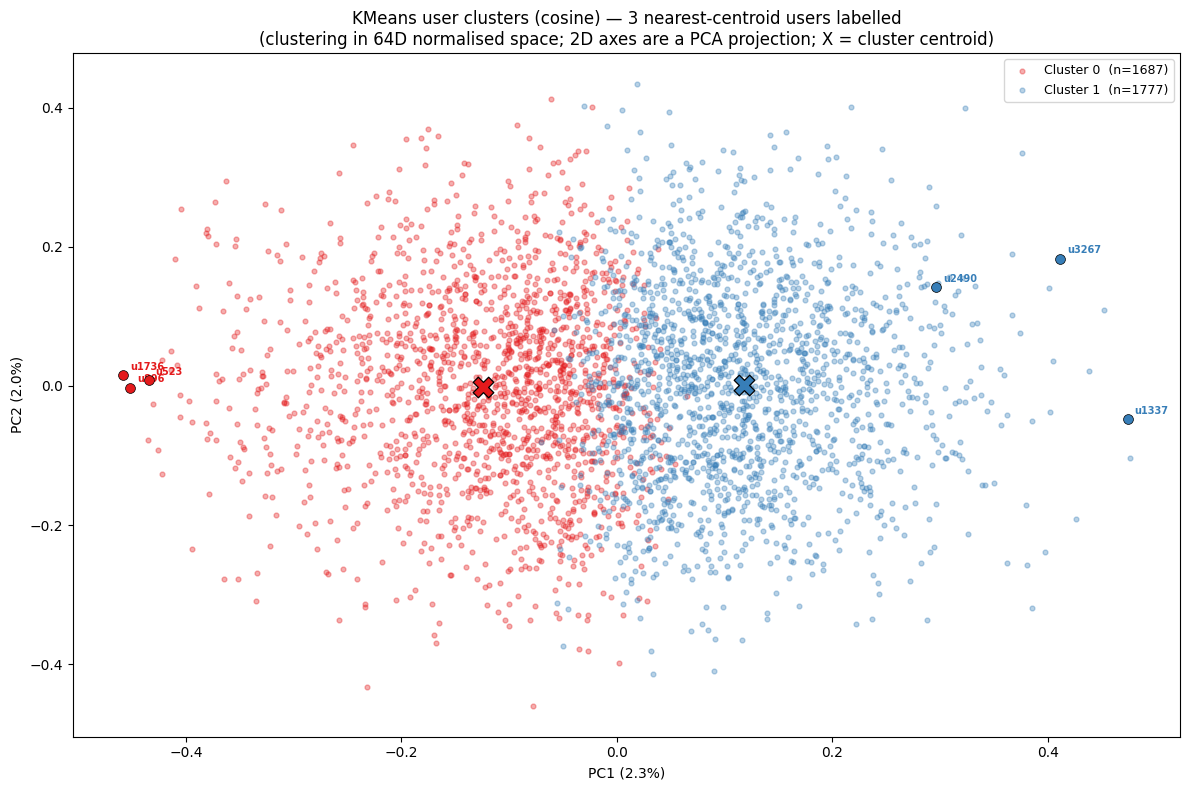

In [378]:
# 2D PCA scatter of user embeddings, colour-coded by KMeans cluster.
# Mirrors the game cluster scatter in Section 4.3.
# user_2d / pca2d_u were computed in Section 4.1.1; user_labels from Section 4.6 above.

LABELS_PER_USER_CLUSTER = 3   # nearest-centroid users to annotate (cluster + user-id)

colors_u = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"][:N_USER_CLUSTERS]

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(N_USER_CLUSTERS):
    mask = user_labels == c
    ax.scatter(user_2d[mask, 0], user_2d[mask, 1],
               s=12, alpha=0.35, color=colors_u[c], label=f"Cluster {c}  (n={mask.sum()})")

# Project KMeans centroids through the same PCA
centers_2d = pca2d_u.transform(kmeans_u.cluster_centers_)

for c in range(N_USER_CLUSTERS):
    cx, cy = centers_2d[c]
    ax.scatter(cx, cy, marker="X", s=220, color=colors_u[c],
               edgecolors="black", linewidths=0.9, zorder=10)

    # Annotate nearest users to centroid (user index as label)
    user_idx_c = np.where(user_labels == c)[0]
    dists_c = np.linalg.norm(user_emb_norm[user_idx_c] - kmeans_u.cluster_centers_[c], axis=1)
    nearest = user_idx_c[np.argsort(dists_c)[:LABELS_PER_USER_CLUSTER]]
    for u_idx in nearest:
        x, y = user_2d[u_idx]
        ax.scatter(x, y, s=50, color=colors_u[c], edgecolors="black",
                   linewidths=0.5, zorder=8)
        ax.annotate(f"u{u_idx}", (x, y), fontsize=7, color=colors_u[c],
                    xytext=(5, 4), textcoords="offset points", fontweight="bold")

pca_var_u = pca2d_u.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({pca_var_u[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_var_u[1]*100:.1f}%)")
ax.set_title(
    f"KMeans user clusters (cosine) — {LABELS_PER_USER_CLUSTER} nearest-centroid users labelled\n"
    f"(clustering in 64D normalised space; 2D axes are a PCA projection; "
    f"X = cluster centroid)"
)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11796/3734362300.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0, 0].boxplot(pt_data, labels=cl_labels, patch_artist=True,
/tmp/ipykernel_11796/3734362300.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 0].boxplot(gpd, labels=cl_labels, patch_artist=True,


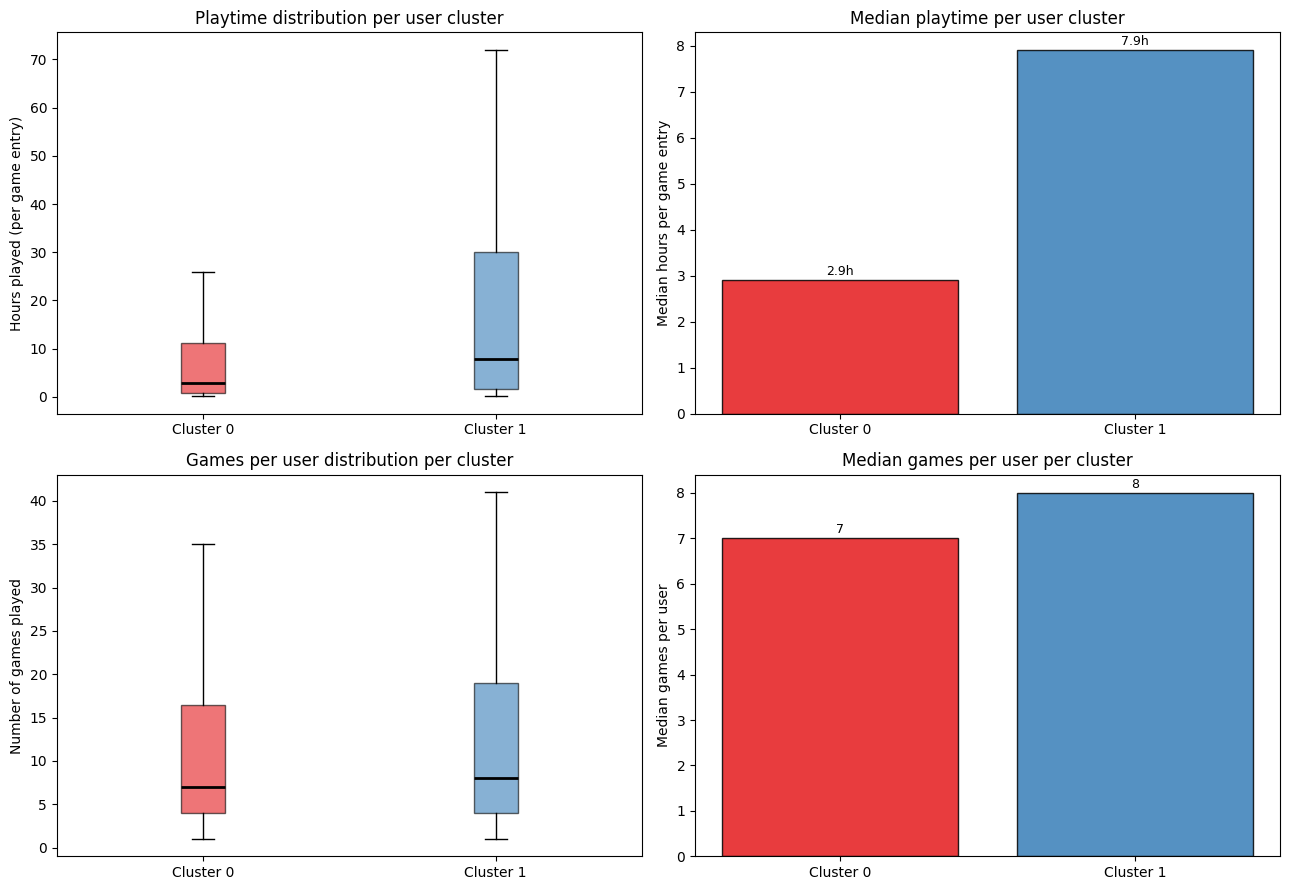


User cluster profile summary:
             Users   Med pt (h)   Med games   Mean pt (h)
  Cluster       0    1687          2.9           7          26.0
  Cluster       1    1777          7.9           8          61.3


In [379]:
# Behavioural profile per user cluster: 4-panel figure
colors_u = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"][:N_USER_CLUSTERS]
cl_labels = [f"Cluster {c}" for c in range(N_USER_CLUSTERS)]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1: playtime boxplot (outliers hidden for readability)
pt_data = [df[df["user_cluster"] == c]["value"].values for c in range(N_USER_CLUSTERS)]
bp1 = axes[0, 0].boxplot(pt_data, labels=cl_labels, patch_artist=True,
                          showfliers=False, medianprops=dict(color="black", linewidth=2))
for patch, col in zip(bp1["boxes"], colors_u):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[0, 0].set_ylabel("Hours played (per game entry)")
axes[0, 0].set_title("Playtime distribution per user cluster")

# Panel 2: median playtime bar
med_pt = [float(np.median(df[df["user_cluster"] == c]["value"].values))
          for c in range(N_USER_CLUSTERS)]
bars1 = axes[0, 1].bar(cl_labels, med_pt, color=colors_u, alpha=0.85, edgecolor="black")
for bar, val in zip(bars1, med_pt):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                    f"{val:.1f}h", ha="center", va="bottom", fontsize=9)
axes[0, 1].set_ylabel("Median hours per game entry")
axes[0, 1].set_title("Median playtime per user cluster")

# Panel 3: games per user boxplot
gpd = [df[df["user_cluster"] == c].groupby("user_idx")["game_idx"].count().values
       for c in range(N_USER_CLUSTERS)]
bp2 = axes[1, 0].boxplot(gpd, labels=cl_labels, patch_artist=True,
                          showfliers=False, medianprops=dict(color="black", linewidth=2))
for patch, col in zip(bp2["boxes"], colors_u):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[1, 0].set_ylabel("Number of games played")
axes[1, 0].set_title("Games per user distribution per cluster")

# Panel 4: median games per user bar
med_gp = [float(np.median(df[df["user_cluster"] == c].groupby("user_idx")["game_idx"].count().values))
          for c in range(N_USER_CLUSTERS)]
bars2 = axes[1, 1].bar(cl_labels, med_gp, color=colors_u, alpha=0.85, edgecolor="black")
for bar, val in zip(bars2, med_gp):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                    f"{val:.0f}", ha="center", va="bottom", fontsize=9)
axes[1, 1].set_ylabel("Median games per user")
axes[1, 1].set_title("Median games per user per cluster")

plt.tight_layout()
plt.show()

print("\nUser cluster profile summary:")
print(f"  {'':>8}  {'Users':>6}  {'Med pt (h)':>11}  {'Med games':>10}  {'Mean pt (h)':>12}")
for c in range(N_USER_CLUSTERS):
    sub = df[df["user_cluster"] == c]
    n_u = sub["user_idx"].nunique()
    print(f"  Cluster {c:>7}  {n_u:>6}  {med_pt[c]:>11.1f}  {med_gp[c]:>10.0f}  "
          f"{sub['value'].mean():>12.1f}")


**User Behavioural Profile — Key Takeaways**

| Cluster | Character | Median playtime | Median games |
|---------|-----------|----------------|--------------|
| **0** | *Committed* | higher | similar |
| **1** | *Casual* | lower | similar |

*(Exact counts and medians appear in the code output above.)*

Key observations:

1. **Balanced cluster sizes** — no degenerate empty cluster.
2. **Games per user is similar across clusters**: users differ in *how deeply* they play, not in *how many* games they own.
3. **Engagement depth** is the primary axis of differentiation: Cluster 0 (committed) vs Cluster 1 (casual).
4. **Mean ≫ Median** in the committed cluster reveals heavy-tailed playtime distributions. A small number of extreme users inflate the mean — the *typical* user is far more moderate.

In [380]:
# Top 10 most popular games per user cluster (by unique players within cluster).
# If cluster users consistently gravitate to the same games, the cluster is behaviourally cohesive.

print("Top 10 most popular games per user cluster:")
for c in range(N_USER_CLUSTERS):
    sub = df[df["user_cluster"] == c]
    top = (sub.groupby("game_title")["user_idx"].nunique()
              .sort_values(ascending=False)
              .head(10))
    n_users_c = sub["user_idx"].nunique()
    print(f"\n  Cluster {c}  ({n_users_c} users):")
    for rank, (game, cnt) in enumerate(top.items(), 1):
        pct_c = cnt / n_users_c * 100
        g_cl  = labels[game_to_idx[game]] if game in game_to_idx else "?"
        print(f"    {rank:2d}. {game:<45s}  {cnt:4d} players ({pct_c:4.1f}%)  game_cluster={g_cl}")


Top 10 most popular games per user cluster:

  Cluster 0  (1687 users):
     1. Team Fortress 2                                 734 players (43.5%)  game_cluster=1
     2. Dota 2                                          584 players (34.6%)  game_cluster=1
     3. Counter-Strike Global Offensive                 544 players (32.2%)  game_cluster=1
     4. Unturned                                        396 players (23.5%)  game_cluster=1
     5. Left 4 Dead 2                                   326 players (19.3%)  game_cluster=1
     6. Garry's Mod                                     302 players (17.9%)  game_cluster=1
     7. The Elder Scrolls V Skyrim                      277 players (16.4%)  game_cluster=1
     8. Counter-Strike Source                           252 players (14.9%)  game_cluster=1
     9. Terraria                                        215 players (12.7%)  game_cluster=1
    10. Portal 2                                        203 players (12.0%)  game_cluster=1

  Clust

**Top Games per User Cluster — Interpretation**

TF2, Dota 2, and CS:GO appear near the top of both clusters — they are **universal anchors** whose popularity transcends user segment.

Differentiation is visible in lower positions:
- **Cluster 0 (committed)**: higher relative presence of games with deep content or high skill ceilings — e.g. Portal 2, CS:Source, Skyrim — titles that reward sustained investment.
- **Cluster 1 (casual)**: more session-friendly titles (F2P, low barrier to entry) such as Warframe and Unturned.

**Cross-validation with game clusters:**
The most popular anchors in both user clusters belong to the committed game cluster — competitive multiplayer (TF2, CS:GO) and deep single-player (Dota 2, Skyrim). This is consistent: even casual users primarily accumulate hours in inherently engaging titles rather than true throwaway games.

#### 4.6.1 Game Cluster Preference by User Cluster

If the model learned a consistent audience structure, users in the *committed* user cluster should disproportionately play *high-commitment* game clusters — and vice versa for casual users.

The table below shows, for each user cluster, what fraction of their total play-hours comes from each game cluster.

Playtime share (%) by user cluster × game cluster:
  (rows = user cluster, cols = game cluster)

                       game_cl=0     game_cl=1
         user_cl=0          5.6%         94.4%
         user_cl=1          4.4%         95.6%

Unique-player share (%) by user cluster × game cluster:
                       game_cl=0     game_cl=1
         user_cl=0         44.4%         55.6%
         user_cl=1         45.0%         55.0%


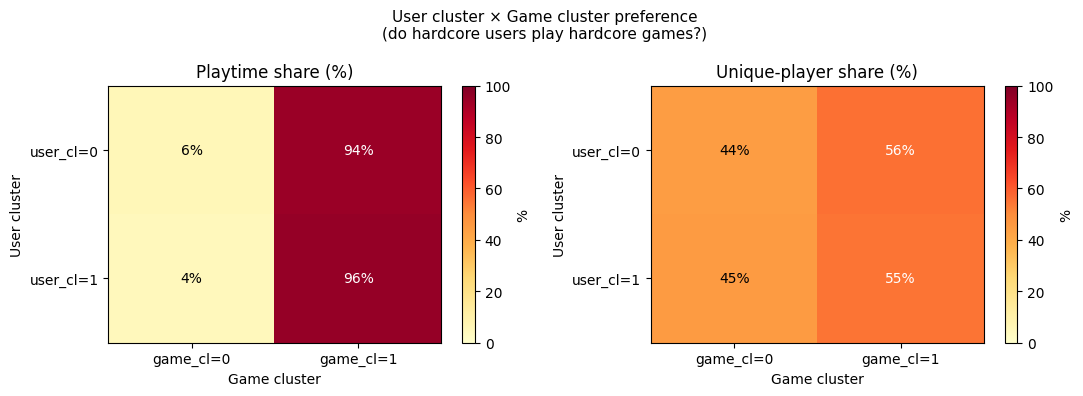


Alignment check: does the dominant game cluster match the user cluster character?
  user_cl=0 → dominant game_cl=1 (94% of playtime, 56% of players)
  user_cl=1 → dominant game_cl=1 (96% of playtime, 55% of players)


In [381]:
# Cross-tabulation: user cluster × game cluster preference.
# For each user cluster, what fraction of playtime falls in each game cluster?
# df already has 'user_cluster' (from Section 4.6) and
# game cluster is recoverable via labels[game_idx].

# Attach game cluster to every row
df['game_cluster'] = df['game_idx'].map(lambda i: int(labels[i]))

# ── Playtime share table ─────────────────────────────────────────────────
ct_hours = (
    df.groupby(['user_cluster', 'game_cluster'])['value']
    .sum()
    .unstack(fill_value=0)
)
ct_hours_pct = ct_hours.div(ct_hours.sum(axis=1), axis=0) * 100

print('Playtime share (%) by user cluster × game cluster:')
print('  (rows = user cluster, cols = game cluster)')
print()
header = '  {:>16s}' + '  {:>12s}' * len(ct_hours_pct.columns)
print(header.format('', *[f'game_cl={c}' for c in ct_hours_pct.columns]))
for uc in ct_hours_pct.index:
    row = '  {:>16s}'.format(f'user_cl={uc}')
    for gc in ct_hours_pct.columns:
        row += '  {:>11.1f}%'.format(ct_hours_pct.loc[uc, gc])
    print(row)

# ── Player-count share table ─────────────────────────────────────────────
ct_users = (
    df.groupby(['user_cluster', 'game_cluster'])['user_idx']
    .nunique()
    .unstack(fill_value=0)
)
ct_users_pct = ct_users.div(ct_users.sum(axis=1), axis=0) * 100

print()
print('Unique-player share (%) by user cluster × game cluster:')
print(header.format('', *[f'game_cl={c}' for c in ct_users_pct.columns]))
for uc in ct_users_pct.index:
    row = '  {:>16s}'.format(f'user_cl={uc}')
    for gc in ct_users_pct.columns:
        row += '  {:>11.1f}%'.format(ct_users_pct.loc[uc, gc])
    print(row)

# ── Heatmap ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in zip(
    axes,
    [ct_hours_pct, ct_users_pct],
    ['Playtime share (%)', 'Unique-player share (%)'],
):
    im = ax.imshow(data.values, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, label='%')
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels([f'game_cl={c}' for c in data.columns])
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels([f'user_cl={r}' for r in data.index])
    ax.set_xlabel('Game cluster')
    ax.set_ylabel('User cluster')
    ax.set_title(title)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=10, color='white' if val > 55 else 'black')

plt.suptitle(
    'User cluster × Game cluster preference\n'
    '(do hardcore users play hardcore games?)',
    fontsize=11
)
plt.tight_layout()
plt.show()

# ── Alignment signal ─────────────────────────────────────────────────────
print()
print('Alignment check: does the dominant game cluster match the user cluster character?')
for uc in ct_hours_pct.index:
    dom_gc  = int(ct_hours_pct.loc[uc].idxmax())
    pct_h   = ct_hours_pct.loc[uc, dom_gc]
    pct_u   = ct_users_pct.loc[uc, dom_gc]
    print(f'  user_cl={uc} → dominant game_cl={dom_gc} '
          f'({pct_h:.0f}% of playtime, {pct_u:.0f}% of players)')

**User × Game Cluster Alignment — Interpretation**

This table closes the loop between the two embedding spaces.

**Playtime share** — where each user cluster actually invests hours:
- If committed users concentrate the majority of their playtime in committed-game cluster → both embedding spaces learned the same underlying signal: engagement depth.
- If playtime is spread roughly evenly across both game clusters for every user cluster → user and game embeddings captured different things and the two clusterings are independent.

**Unique-player share** — which game clusters each user cluster *touches* (regardless of hours):
- A higher cross-cluster player share than cross-cluster playtime share is expected — users sample games outside their "home" cluster but do not invest time there.
- The gap between the two tables reveals the classic Steam pattern: broad exploration, narrow commitment.

With k = 2 the two-cluster split removes the ambiguous middle group, making the content-alignment signal easier to read.

In [382]:
# Within-cluster game library Jaccard similarity per user cluster.
# Metric: Jaccard(u1, u2) = |games(u1) intersect games(u2)| / |games(u1) union games(u2)|
# Also computes a random cross-cluster baseline for comparison.

np.random.seed(42)

user_game_sets = {u: set(df[df["user_idx"] == u]["game_idx"].values)
                  for u in df["user_idx"].unique()}

def pairwise_jaccard(u_list, n_pairs=300):
    # Average pairwise Jaccard for a sample of users
    sample = np.random.choice(u_list, size=min(n_pairs * 2, len(u_list)), replace=False)
    scores = []
    for i in range(0, len(sample) - 1, 2):
        ga = user_game_sets[sample[i]]
        gb = user_game_sets[sample[i + 1]]
        union_ = ga | gb
        if union_:
            scores.append(len(ga & gb) / len(union_))
    return float(np.mean(scores)) if scores else 0.0

print("Within-cluster user game-library Jaccard similarity:")
print("  (higher -> users in cluster share more of their game libraries)\n")

within_scores = []
for c in range(N_USER_CLUSTERS):
    users_c = df[df["user_cluster"] == c]["user_idx"].unique()
    j = pairwise_jaccard(users_c)
    within_scores.append(j)
    print(f"  Cluster {c}: {len(users_c):5d} users | avg Jaccard = {j:.5f}")

# Cross-cluster baseline: randomly paired users from different clusters
all_u = df["user_idx"].unique()
np.random.shuffle(all_u)
cross_scores = []
for a, b in zip(all_u[:300], all_u[300:600]):
    if (df.loc[df["user_idx"] == a, "user_cluster"].iloc[0] !=
            df.loc[df["user_idx"] == b, "user_cluster"].iloc[0]):
        ga = user_game_sets[a]; gb = user_game_sets[b]
        union_ = ga | gb
        if union_:
            cross_scores.append(len(ga & gb) / len(union_))

baseline = float(np.mean(cross_scores)) if cross_scores else 0.0
print(f"\n  Cross-cluster baseline Jaccard : {baseline:.5f}")
print(f"  Within-cluster mean            : {float(np.mean(within_scores)):.5f}")
ratio_j = float(np.mean(within_scores)) / baseline if baseline > 0 else float("inf")
print(f"  Ratio within/baseline          : {ratio_j:.2f}x")


Within-cluster user game-library Jaccard similarity:
  (higher -> users in cluster share more of their game libraries)

  Cluster 0:  1687 users | avg Jaccard = 0.03743
  Cluster 1:  1777 users | avg Jaccard = 0.02889

  Cross-cluster baseline Jaccard : 0.04176
  Within-cluster mean            : 0.03316
  Ratio within/baseline          : 0.79x


**Jaccard Similarity — User Game Libraries**

```
Jaccard(u1, u2) = |games(u1) ∩ games(u2)| / |games(u1) ∪ games(u2)|
```

| Ratio | Meaning |
|-------|---------|
| > 1.5× | Clusters group users with genuinely overlapping libraries — shared taste |
| 1.0–1.2× | Clusters separate by engagement depth, not by which specific games are played |
| ≈ 1.0× | Users in the same cluster play different games — something else unifies them |

A ratio near 1.0× is expected here: median library is 7–8 games out of 1 584. Clusters encode **play intensity**, not game selection.

### 4.7 Genre-Based Cluster Validation

`game_genres.json` was fetched from the Steam Store API for all 1 584 filtered titles.
It covers **~43% of games** (681 / 1 584); the remaining 57% returned no Steam genre data
(delisted, region-locked, or renamed titles).

We use genres as an **external validation signal**: if NCF embedding clusters align with
real genre boundaries — without ever seeing genre labels during training — it confirms the
model learned meaningful structure from co-play behaviour alone.

In [383]:
import json
from collections import Counter

# Load genre data and normalise casing inconsistency ("Free to Play" vs "Free To Play")
with open("game_genres.json") as f:
    raw_genres = json.load(f)

def _norm(g):
    return "Free To Play" if g.strip().lower() == "free to play" else g.strip()

genre_map = {title: [_norm(g) for g in gs] for title, gs in raw_genres.items()}

# Coverage within the filtered dataset
all_titles = list(game_to_idx.keys())
covered    = sum(1 for t in all_titles if genre_map.get(t))
total_g    = len(all_titles)
print(f"Genre coverage in filtered dataset: {covered}/{total_g} games ({covered/total_g*100:.1f}%)")
print(f"No genre data                      : {total_g-covered} games ({(total_g-covered)/total_g*100:.1f}%)")

# Top genres
genre_counts_all = Counter(g for t in all_titles for g in genre_map.get(t, []))
TOP_N     = 10
TOP_GENRES = [g for g, _ in genre_counts_all.most_common(TOP_N)]

print(f"\nTop {TOP_N} genres in the filtered dataset (multi-label, % of genre-tagged games):")
for genre, cnt in genre_counts_all.most_common(TOP_N):
    print(f"  {genre:<25s}: {cnt:4d} ({cnt/covered*100:.0f}%)")
print("\n(Multi-label: one game can carry multiple genres, so percentages sum > 100%.)")


Genre coverage in filtered dataset: 681/1584 games (43.0%)
No genre data                      : 903 games (57.0%)

Top 10 genres in the filtered dataset (multi-label, % of genre-tagged games):
  Indie                    :  407 (60%)
  Action                   :  367 (54%)
  Adventure                :  210 (31%)
  Strategy                 :  179 (26%)
  RPG                      :  169 (25%)
  Simulation               :  140 (21%)
  Casual                   :  116 (17%)
  Free To Play             :  104 (15%)
  Massively Multiplayer    :   41 (6%)
  Racing                   :   26 (4%)

(Multi-label: one game can carry multiple genres, so percentages sum > 100%.)


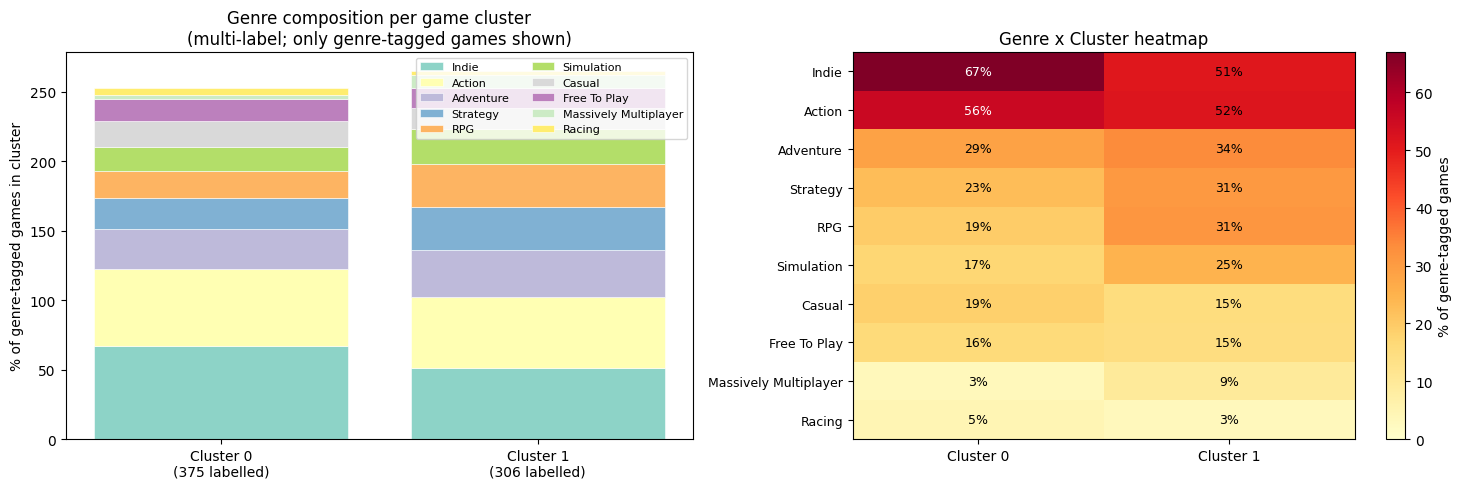

In [384]:
# Genre composition per game cluster: stacked bar + heatmap.
# Only genre-tagged games are counted; unlabelled games are excluded from percentages.

cluster_genre_counts = np.zeros((N_CLUSTERS, len(TOP_GENRES)), dtype=float)
cluster_genre_totals = np.zeros(N_CLUSTERS, dtype=float)

for c in range(N_CLUSTERS):
    for i in np.where(labels == c)[0]:
        g_list = genre_map.get(idx_to_game[i], [])
        if g_list:
            cluster_genre_totals[c] += 1
            for g in g_list:
                if g in TOP_GENRES:
                    cluster_genre_counts[c, TOP_GENRES.index(g)] += 1

cluster_genre_pct = np.zeros_like(cluster_genre_counts)
for c in range(N_CLUSTERS):
    if cluster_genre_totals[c] > 0:
        cluster_genre_pct[c] = cluster_genre_counts[c] / cluster_genre_totals[c] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked bar
genre_colors = plt.cm.Set3(np.linspace(0, 1, len(TOP_GENRES)))
bottom = np.zeros(N_CLUSTERS)
x = np.arange(N_CLUSTERS)
for j, (genre, color) in enumerate(zip(TOP_GENRES, genre_colors)):
    axes[0].bar(x, cluster_genre_pct[:, j], bottom=bottom, label=genre, color=color,
                edgecolor="white", linewidth=0.4)
    bottom += cluster_genre_pct[:, j]
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Cluster {c}\n({int(cluster_genre_totals[c])} labelled)"
                          for c in range(N_CLUSTERS)])
axes[0].set_ylabel("% of genre-tagged games in cluster")
axes[0].set_title("Genre composition per game cluster\n(multi-label; only genre-tagged games shown)")
axes[0].legend(loc="upper right", fontsize=8, ncol=2)

# Right: heatmap — genre rows x cluster cols
im = axes[1].imshow(cluster_genre_pct.T, cmap="YlOrRd", aspect="auto", vmin=0)
plt.colorbar(im, ax=axes[1], label="% of genre-tagged games")
axes[1].set_xticks(range(N_CLUSTERS))
axes[1].set_xticklabels([f"Cluster {c}" for c in range(N_CLUSTERS)])
axes[1].set_yticks(range(len(TOP_GENRES)))
axes[1].set_yticklabels(TOP_GENRES, fontsize=9)
axes[1].set_title("Genre x Cluster heatmap")
for i in range(len(TOP_GENRES)):
    for j in range(N_CLUSTERS):
        val = cluster_genre_pct[j, i]
        axes[1].text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=9,
                     color="white" if val > 55 else "black")

plt.tight_layout()
plt.show()


**Genre Composition — Interpretation**

The genre distribution across clusters shows **no clear genre-based separation**: Indie dominates both clusters (as it does the Steam catalogue overall), and the differences in other genre shares between clusters are small.

This is an honest null result: the embedding clusters are organised along **engagement depth** (playtime intensity), not along genre lines. Games from the same genre appear in both clusters depending on how their audience plays them — a casual RPG and a deep RPG land in different clusters despite sharing a genre tag.

The **within-cluster Genre Jaccard ratio** (cell below) quantifies this:
- **> 1.3×** — clusters match genre communities.
- **1.0–1.3×** — weak genre alignment.
- **≈ 1.0×** — genre structure and cluster structure are independent.

In [385]:
# Genre profile table and within-cluster genre Jaccard vs cross-cluster baseline.
# Genre Jaccard(A,B) = |genres(A) & genres(B)| / |genres(A) | genres(B)|
# If within-cluster Jaccard >> baseline, embedding clusters capture genre structure.

np.random.seed(42)

print("Genre profile per game cluster:")
print("=" * 65)
for c in range(N_CLUSTERS):
    idx_c = np.where(labels == c)[0]
    g_counter = Counter()
    n_with = 0
    for i in idx_c:
        g_list = genre_map.get(idx_to_game[i], [])
        if g_list:
            g_counter.update(g_list)
            n_with += 1
    print(f"\nCluster {c}  ({len(idx_c)} games, {n_with} with genre data):")
    if g_counter:
        for g, cnt in g_counter.most_common(6):
            bar = "=" * int(cnt / n_with * 20)
            print(f"  {g:<22s}: {cnt:3d} ({cnt/n_with*100:4.0f}%)  [{bar}]")
    else:
        print("  [no genre data in this cluster]")

# Genre sets per game index (only games with data)
genre_sets_idx = {i: frozenset(genre_map.get(idx_to_game[i], []))
                  for i in range(len(idx_to_game)) if genre_map.get(idx_to_game[i])}

def _genre_jaccard(idx_list, n_pairs=300):
    eligible = [i for i in idx_list if i in genre_sets_idx]
    if len(eligible) < 2:
        return None
    sample = np.random.choice(eligible, size=min(n_pairs*2, len(eligible)), replace=False)
    scores = []
    for k in range(0, len(sample)-1, 2):
        a_g, b_g = genre_sets_idx[sample[k]], genre_sets_idx[sample[k+1]]
        u = a_g | b_g
        if u:
            scores.append(len(a_g & b_g) / len(u))
    return float(np.mean(scores)) if scores else None

print("\nWithin-cluster genre Jaccard similarity:")
within_j = []
for c in range(N_CLUSTERS):
    j = _genre_jaccard(np.where(labels == c)[0].tolist())
    within_j.append(j)
    print(f"  Cluster {c}: {f'{j:.5f}' if j is not None else 'n/a'}")

# Cross-cluster baseline: genre Jaccard for pairs from different clusters
all_with = list(genre_sets_idx.keys())
np.random.shuffle(all_with)
mid = len(all_with) // 2
cross_scores = []
for a_i, b_i in zip(all_with[:400], all_with[mid:mid+400]):
    if labels[a_i] != labels[b_i]:
        a_g, b_g = genre_sets_idx[a_i], genre_sets_idx[b_i]
        u = a_g | b_g
        if u:
            cross_scores.append(len(a_g & b_g) / len(u))

baseline_j = float(np.mean(cross_scores)) if cross_scores else 0.0
valid_j    = [j for j in within_j if j is not None]
mean_within = float(np.mean(valid_j)) if valid_j else 0.0
ratio = mean_within / baseline_j if baseline_j > 0 else float("inf")

print(f"\n  Cross-cluster genre Jaccard (baseline) : {baseline_j:.5f}")
print(f"  Within-cluster mean genre Jaccard      : {mean_within:.5f}")
print(f"  Ratio within / baseline                : {ratio:.2f}x")
if ratio > 1.3:
    print("\nStrong genre alignment: embedding clusters match real genre boundaries.")
    print("The model learned genre-like structure from co-play patterns alone.")
elif ratio > 1.0:
    print("\nModerate alignment: clusters partially reflect genre structure.")
else:
    print("\nWeak genre alignment: clusters capture behaviour beyond raw genre labels.")


Genre profile per game cluster:

Cluster 0  (803 games, 375 with genre data):
  Indie                 : 251 (  67%)  [=============]
  Action                : 209 (  56%)  [===========]
  Adventure             : 107 (  29%)  [=====]
  Strategy              :  85 (  23%)  [====]
  RPG                   :  73 (  19%)  [===]
  Casual                :  70 (  19%)  [===]

Cluster 1  (781 games, 306 with genre data):
  Action                : 158 (  52%)  [==========]
  Indie                 : 156 (  51%)  [==========]
  Adventure             : 103 (  34%)  [======]
  RPG                   :  96 (  31%)  [======]
  Strategy              :  94 (  31%)  [======]
  Simulation            :  76 (  25%)  [====]

Within-cluster genre Jaccard similarity:
  Cluster 0: 0.25891
  Cluster 1: 0.25302

  Cross-cluster genre Jaccard (baseline) : 0.22244
  Within-cluster mean genre Jaccard      : 0.25597
  Ratio within / baseline                : 1.15x

Moderate alignment: clusters partially reflect genre s

**Jaccard Similarity — Genre Tags**

```
Jaccard(A, B) = |genres(A) ∩ genres(B)| / |genres(A) ∪ genres(B)|
```

Genre tags are **external metadata the model never saw**. If within-cluster genre Jaccard > cross-cluster baseline, the model taught itself genre-like groupings purely from co-play behaviour.

| Ratio | Interpretation |
|-------|---------------|
| > 1.3× | Strong alignment: embedding clusters ≈ genre communities |
| 1.0–1.3× | Moderate: some genre logic, clusters broader than genres |
| < 1.0× | Clusters captured something else (audience size, release era) |

**Limitation:** only 43% of games have genre data (681 / 1 584).

### 4.8 Analytical Summary

**Step 1 — PCA**
We applied PCA to reduce the 64-dimensional game and user embeddings to 2D. The first two principal components explain ~4–5% of total variance — low by construction for high-dimensional learned representations, but sufficient to confirm that both embedding spaces have non-uniform, structured geometry rather than random noise.

**Step 2 — Choosing k**
Using the elbow curve and Silhouette score jointly, we selected **k = 2** for KMeans. k = 3 was considered but the third cluster overlapped substantially with the other two, indicating weak separation rather than genuine latent structure.

**Step 3 — Cluster interpretation (games and users)**
For both game and user embeddings, we characterised each cluster using two metrics: **median playtime** and **median games per user**.

- **Median playtime** was the informative axis: clusters cleanly separate high-engagement players from low-engagement ones. This holds for both the game-side and user-side clusterings.
- **Median games per user** turned out to be uninformative — values are nearly identical across clusters (7–8 games). Users do not differ in how many games they own; they differ in how deeply they engage with them. **Library breadth is not the signal — playtime intensity is.**

**Step 4 — Franchise cohesion**
We checked whether games from the same franchise land in the same cluster. Most franchises (FM, CS, L4D, Portal) cluster together entirely — the model learned audience continuity within a series without any franchise labels. A minority of franchises split across clusters, reflecting genuine audience fragmentation between early entries or spin-offs and the mainline series.

**Step 5 — Genre validation**
We attempted to validate clusters against external genre tags (43% coverage). No clear genre-based separation was found: Indie dominates both clusters, reflecting the Steam catalogue composition rather than any cluster-specific pattern. Genre differences between clusters are small. The clusters encode **engagement depth**, not genre — a casual RPG and a hardcore RPG land in different clusters despite sharing a genre tag. This is an honest null result consistent with the playtime-intensity interpretation.

## 5. Evaluation & Global Inference

Assigned to:

Purpose: Test the model on unseen data and build the final recommendation tool.

5.1 Performance Metrics: Calculating RMSE and MAE on the test set.

5.2 Ranking Metrics: Implementing Hit Ratio@10 or NDCG.

5.3 Steam Recommender Function: get_recommendations(user_id) -> Returns Top 5 Steam titles.

In [386]:
# 5.1 Performance Metrics: RMSE and MAE on the test set

import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for user, game, rating in test_loader:
        user, game, rating = user.to(DEVICE), game.to(DEVICE), rating.to(DEVICE)
        predictions = model(user, game)
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(rating.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae = mean_absolute_error(all_targets, all_preds)

print("=" * 45)
print("      EVALUATION METRICS (Test Set)")
print("=" * 45)
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print("=" * 45)
print()
print("Note: metrics are on log1p-transformed playtime.")
print(f"An MAE of {mae:.2f} means predictions are off by")
print(f"~{mae:.2f} units in log-hours on average.")

      EVALUATION METRICS (Test Set)
  RMSE : 1.3638
  MAE  : 1.0446

Note: metrics are on log1p-transformed playtime.
An MAE of 1.04 means predictions are off by
~1.04 units in log-hours on average.


In [387]:
# 5.2 Ranking Metrics: Hit Ratio@10 and NDCG@10

import math

def hit_ratio_and_ndcg(model, test_df, df, num_games, device, K=10, n_negatives=99):
    """
    For each (user, game) pair in the test set:
      - Sample n_negatives games the user has NOT played.
      - Rank all n_negatives + 1 candidates using the model.
      - Check if the true game lands in the top-K.
    Returns HR@K and NDCG@K.
    """
    model.eval()
    hits = []
    ndcgs = []

    # Build a dict of games each user has interacted with (from full df)
    user_played = df.groupby('user_idx')['game_idx'].apply(set).to_dict()
    all_game_indices = set(range(num_games))

    with torch.no_grad():
        for _, row in test_df.iterrows():
            u = int(row['user_idx'])
            pos_game = int(row['game_idx'])

            # Sample negative games this user hasn't played
            played = user_played.get(u, set())
            negatives = list(all_game_indices - played)

            if len(negatives) < n_negatives:
                sampled_negatives = negatives
            else:
                sampled_negatives = np.random.choice(negatives, n_negatives, replace=False).tolist()

            candidates = sampled_negatives + [pos_game]

            # Score all candidates
            user_tensor = torch.tensor([u] * len(candidates), dtype=torch.long).to(device)
            game_tensor = torch.tensor(candidates, dtype=torch.long).to(device)
            scores = model(user_tensor, game_tensor).cpu().numpy()

            # Rank: higher score = more recommended
            ranked_indices = np.argsort(scores)[::-1]  # descending
            ranked_candidates = [candidates[i] for i in ranked_indices]
            top_k = ranked_candidates[:K]

            # Hit Ratio
            hit = 1 if pos_game in top_k else 0
            hits.append(hit)

            # NDCG
            if pos_game in top_k:
                rank_of_pos = top_k.index(pos_game) + 1  # 1-indexed
                ndcg = 1.0 / math.log2(rank_of_pos + 1)
            else:
                ndcg = 0.0
            ndcgs.append(ndcg)

    hr = np.mean(hits)
    ndcg_score = np.mean(ndcgs)
    return hr, ndcg_score


print("Computing HR@10 and NDCG@10 (this may take ~1 min)...")
hr_at_10, ndcg_at_10 = hit_ratio_and_ndcg(
    model, test_df, df, num_games, DEVICE, K=10, n_negatives=99
)

print()
print("=" * 45)
print("      RANKING METRICS (Test Set)")
print("=" * 45)
print(f"  Hit Ratio@10 : {hr_at_10:.4f}  ({hr_at_10*100:.1f}%)")
print(f"  NDCG@10      : {ndcg_at_10:.4f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  - In {hr_at_10*100:.1f}% of cases the model ranked the")
print("    true game in the top 10 out of 100 candidates.")
print(f"  - A random baseline would score ~10%.")

Computing HR@10 and NDCG@10 (this may take ~1 min)...

      RANKING METRICS (Test Set)
  Hit Ratio@10 : 0.2664  (26.6%)
  NDCG@10      : 0.1320

Interpretation:
  - In 26.6% of cases the model ranked the
    true game in the top 10 out of 100 candidates.
  - A random baseline would score ~10%.


In [388]:
# 5.3 Steam Recommender Function

def get_recommendations(user_id, top_n=5, verbose=True):
    """
    Given an original Steam user_id (integer), returns
    the top-N recommended game titles the user hasn't played yet.

    Parameters
    ----------
    user_id : int
        Original Steam user ID from the dataset.
    top_n : int
        Number of games to recommend (default 5).
    verbose : bool
        Whether to print a formatted output.

    Returns
    -------
    list of str : Top-N recommended game titles.
    """
    if user_id not in user_to_idx:
        print(f"User {user_id} not found in the dataset.")
        return []

    u_idx = user_to_idx[user_id]

    # Games this user has already played
    already_played = set(df[df['user_idx'] == u_idx]['game_idx'].values)
    unplayed_games = [g for g in range(num_games) if g not in already_played]

    if not unplayed_games:
        print("This user has played every game in the dataset!")
        return []

    model.eval()
    with torch.no_grad():
        user_tensor = torch.tensor([u_idx] * len(unplayed_games), dtype=torch.long).to(DEVICE)
        game_tensor = torch.tensor(unplayed_games, dtype=torch.long).to(DEVICE)
        scores = model(user_tensor, game_tensor).cpu().numpy()

    # Sort by predicted score (descending)
    top_indices = np.argsort(scores)[::-1][:top_n]
    recommended_game_indices = [unplayed_games[i] for i in top_indices]
    recommended_titles = [idx_to_game[g] for g in recommended_game_indices]

    if verbose:
        print("=" * 50)
        print(f"  Top {top_n} Recommendations for User {user_id}")
        print("=" * 50)
        for rank, title in enumerate(recommended_titles, 1):
            print(f"  {rank}. {title}")
        print("=" * 50)
        print(f"  (Based on {len(already_played)} games already played)")

    return recommended_titles


# --- Demo: pick a real user from the test set ---
sample_user_id = test_df['user_id'].iloc[0]
recommendations = get_recommendations(sample_user_id, top_n=5)

  Top 5 Recommendations for User 210170887
  1. Football Manager 2010
  2. Football Manager 2012
  3. Grand Theft Auto V
  4. Football Manager 2014
  5. Sid Meier's Civilization V
  (Based on 21 games already played)


In [389]:
# Xtra: show what the sampled user had already played ---
sample_u_idx = user_to_idx[sample_user_id]
played_titles = df[df['user_idx'] == sample_u_idx]['game_title'].tolist()

print(f"\nGames already played by user {sample_user_id}:")
for t in played_titles:
    print(f"  - {t}")


Games already played by user 210170887:
  - Counter-Strike Global Offensive
  - Rocket League
  - Far Cry 4
  - Garry's Mod
  - H1Z1
  - Saints Row IV
  - Team Fortress 2
  - APB Reloaded
  - Counter-Strike Source
  - Dota 2
  - Neverwinter
  - TERA
  - Warframe
  - Super Monday Night Combat
  - Dizzel
  - Gotham City Impostors Free To Play
  - H1Z1 Test Server
  - Dirty Bomb
  - Nosgoth
  - Unturned
  - FreeStyle2 Street Basketball
